# Regional drivers (JODI)

Static notebook — **pandas** tables and **matplotlib** charts.

- **Demand** (kb/d) and **ending stocks** (mbbl)
- **YoY** — same month vs last year · **MoM** — vs prior month
- **Balanced panel** (lag = 0): reporters with ref, YoY, and MoM data

Edit **`GEOGRAPHY`** and **`METRICS`** in Setup, then **Run All**. Use **Section 10** to drill into countries flagged in the regional view.


## 1. Setup


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from matplotlib.colors import TwoSlopeNorm

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

POS = "#2ca02c"
NEG = "#d62728"
TOTAL = "#4472C4"

# --- analysis config ---
METRICS = ["demand", "stocks"]
METRIC_UNITS = {"demand": "kb/d", "stocks": "mbbl"}
PRODUCT = "TOTPRODS"


def _project_root() -> Path:
    here = Path.cwd()
    for candidate in [here, *here.parents]:
        if (candidate / "scripts" / "update_jodi.py").exists():
            return candidate
        if (candidate / "country_oil_scraper" / "scripts" / "update_jodi.py").exists():
            return candidate / "country_oil_scraper"
    raise RuntimeError(f"Cannot find project root from {here}")


def plot_waterfall(ax, labels, values, title: str) -> None:
    """Country-level changes stacking to a total bar."""
    cum = 0.0
    xs, bs, hs, cs = [], [], [], []
    for val in values:
        xs.append(len(xs))
        if val >= 0:
            bs.append(cum)
            hs.append(val)
        else:
            bs.append(cum + val)
            hs.append(-val)
        cs.append(POS if val >= 0 else NEG)
        cum += val
    ax.bar(xs, hs, bottom=bs, color=cs, edgecolor="white", linewidth=0.5)
    t = len(labels)
    if cum >= 0:
        ax.bar(t, cum, bottom=0, color=TOTAL, edgecolor="white")
    else:
        ax.bar(t, -cum, bottom=cum, color=TOTAL, edgecolor="white")
    ax.set_xticks(list(range(t + 1)))
    ax.set_xticklabels([*labels, "Total"], rotation=45, ha="right")
    ax.set_title(title)
    ax.axhline(0, color="black", linewidth=0.8)


ROOT = _project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from analytics.jodi_dashboard import (
    METRIC_LABELS,
    configure,
    CONSOLIDATED_ASIA_PACIFIC,
    GEO_ALIASES,
    GLOBAL_KEY,
    REGION_PREFIX,
    DRIVER_LAG_MONTHS,
    resolve_geography,
    assess_reporter_freshness,
    build_regional_driver_summary,
    build_country_contribution_table,
    build_country_product_breakdown,
    build_balanced_panel,
    build_common_panel,
    build_product_change_summary,
    plot_product_change_bars,
    get_dashboard_series,
    product_label,
)

# --- geography config (pick one, then Run All) ---
GEOGRAPHY = REGION_PREFIX + CONSOLIDATED_ASIA_PACIFIC
#GEOGRAPHY = REGION_PREFIX + "Europe"
# GEOGRAPHY = REGION_PREFIX + "Middle East"
# GEOGRAPHY = REGION_PREFIX + "North America"
# GEOGRAPHY = "GB"  # single country (JODI ISO; UK → GB alias supported)


def country_contrib_matrix(
    summary: pd.DataFrame,
    geography: str,
    lag_months: int,
    metric: str,
    value_col: str = "yoy_change",
) -> pd.DataFrame:
    frames = []
    for code in summary["product_code"]:
        tbl = build_country_contribution_table(
            geography, code, lag_months=lag_months, metric=metric,
        )
        if tbl.empty:
            continue
        part = tbl[["country", value_col]].copy()
        part["product_code"] = code
        frames.append(part)
    if not frames:
        return pd.DataFrame()
    long = pd.concat(frames, ignore_index=True)
    return long.pivot(index="country", columns="product_code", values=value_col)


def plot_country_product_heatmap(
    matrix: pd.DataFrame, title: str, cbar_label: str,
) -> None:
    col_labels = [product_label(c) for c in matrix.columns]
    row_labels = matrix.index.tolist()
    data = matrix.to_numpy(dtype=float)
    vmax = np.nanmax(np.abs(data))
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    fig, ax = plt.subplots(
        figsize=(max(10, len(matrix.columns) * 1.1), max(6, len(matrix) * 0.35))
    )
    im = ax.imshow(data, aspect="auto", cmap="RdYlGn", norm=norm)
    ax.set_xticks(np.arange(len(col_labels)))
    ax.set_xticklabels(col_labels, rotation=45, ha="right")
    ax.set_yticks(np.arange(len(row_labels)))
    ax.set_yticklabels(row_labels)
    ax.set_title(title)
    cbar = fig.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label(cbar_label)
    plt.tight_layout()
    plt.show()


PROCESSED = ROOT / "data" / "processed" / "jodi"
df_sec = pd.read_parquet(PROCESSED / "jodi_secondary.parquet")
df_pri = pd.read_parquet(PROCESSED / "jodi_primary.parquet")

COUNTRY_NAMES = (
    pd.concat([df_sec[["ref_area", "country_name"]], df_pri[["ref_area", "country_name"]]])
    .dropna()
    .drop_duplicates("ref_area")
    .set_index("ref_area")["country_name"]
    .astype(str)
    .to_dict()
)

configure(df_sec, df_pri, COUNTRY_NAMES)

_geo_codes, GEO_LABEL = resolve_geography(GEOGRAPHY)
print(f"Region: {GEO_LABEL} ({len(_geo_codes)} mapped countries)")
print(f"Metrics: {', '.join(METRIC_LABELS[m] for m in METRICS)}")
print(f"Lag={DRIVER_LAG_MONTHS} mo | secondary rows={len(df_sec):,}")



Region: Asia Pacific (31 mapped countries)
Metrics: Demand, Ending stocks
Lag=0 mo | secondary rows=15,583,732


## 2. Load data


In [2]:
by_metric: dict = {}

for metric in METRICS:
    summary = build_regional_driver_summary(
        GEOGRAPHY, lag_months=DRIVER_LAG_MONTHS, metric=metric,
    )
    contrib = build_country_contribution_table(
        GEOGRAPHY, PRODUCT, lag_months=DRIVER_LAG_MONTHS, metric=metric,
    )
    panel, ref_y, ref_m, peer = build_balanced_panel(
        GEOGRAPHY, PRODUCT, lag_months=DRIVER_LAG_MONTHS, metric=metric,
    )
    fresh = assess_reporter_freshness(
        GEOGRAPHY, PRODUCT, metric, lag_months=DRIVER_LAG_MONTHS,
    )
    in_panel = set(contrib["ref_area"].astype(str)) if not contrib.empty else set()
    audit = fresh.assign(
        in_panel=fresh["ref_area"].astype(str).isin(in_panel),
        latest_month=pd.to_datetime(fresh["latest_date"], errors="coerce").dt.strftime("%Y-%m"),
    )
    by_metric[metric] = {
        "summary": summary,
        "contrib": contrib,
        "panel": panel,
        "ref_month": f"{ref_y}-{ref_m:02d}",
        "peer_month": peer.strftime("%Y-%m") if pd.notna(peer) else "—",
        "audit": audit,
    }
    print(
        f"{METRIC_LABELS[metric]}: {len(summary)} products, "
        f"TOTPRODS panel={len(contrib)} countries (ref {by_metric[metric]['ref_month']})"
    )



Demand: 9 products, TOTPRODS panel=12 countries (ref 2026-07)
Ending stocks: 9 products, TOTPRODS panel=10 countries (ref 2026-07)


### Global demand by product (common panel)

Same **ref month** and **country panel** for every product (`TOTPRODS`-anchored balanced panel, `lag=0`). Avoids artificial product moves when reporting coverage differs by line item.

### Global — demand change (kb/d) · ref 2026-07 · common panel n=50 (TOTPRODS-anchored) · lag=0 mo

,product,month,level_kb_d,yoy_change,yoy_pct,mom_change,mom_pct,vs_5y_range,panel_n,excluded_n
0,Total ref products (TOTPRODS),2026-07,51566.0,-1595.0,-3.0,119.0,0.2,10% of 5y range,41,77
1,Gas/diesel oil (GASDIES),2026-07,13410.0,-1242.0,-8.5,-1129.0,-7.8,Below 5y low,41,77
2,Jet kerosene (subset of kerosenes) (JETKERO),2026-07,4562.0,-73.0,-1.6,159.0,3.6,92% of 5y range,41,77
3,LPG (LPG),2026-07,3299.0,-310.0,-8.6,-104.0,-3.1,Below 5y low,41,77
4,Motor & aviation gasoline (GASOLINE),2026-07,15839.0,-36.0,-0.2,252.0,1.6,91% of 5y range,41,77
5,Naphtha (NAPHTHA),2026-07,2714.0,-706.0,-20.6,-322.0,-10.6,Below 5y low,41,77
6,Other ref products (ONONSPEC),2026-07,9461.0,954.0,11.2,1559.0,19.7,Above 5y high,41,77
7,Residual fuel oil (RESFUEL),2026-07,2011.0,-185.0,-8.4,-276.0,-12.1,Below 5y low,41,77


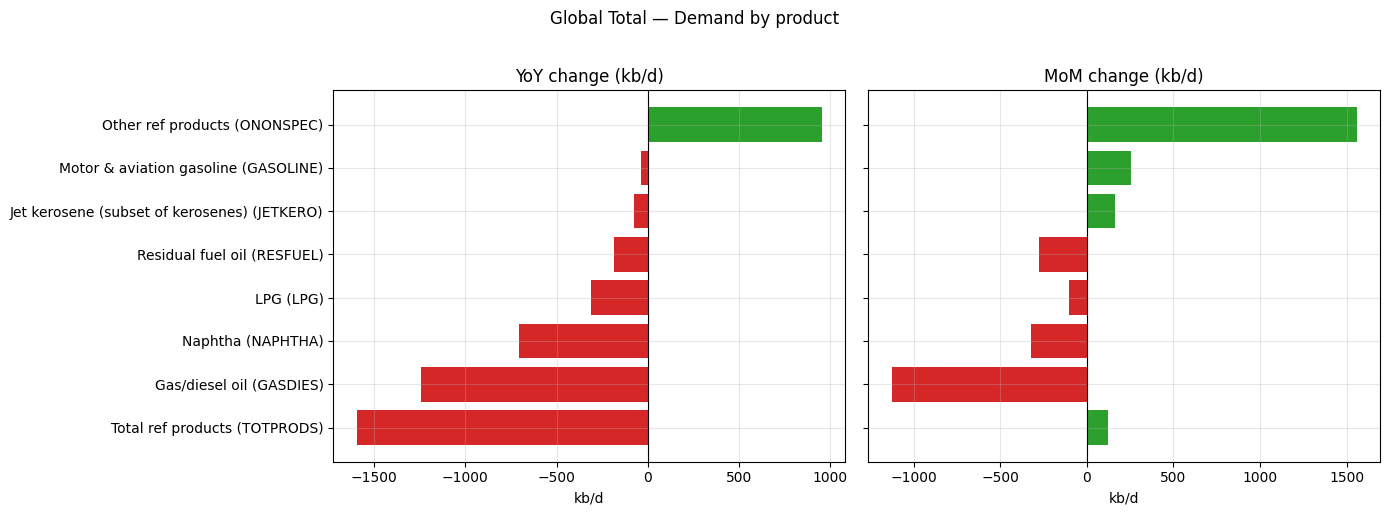

In [3]:
GLOBAL_GEOGRAPHY = GLOBAL_KEY
_global_codes, GLOBAL_LABEL = resolve_geography(GLOBAL_GEOGRAPHY)

_global_panel, _g_ry, _g_rm, _g_month, _g_excl = build_common_panel(
    GLOBAL_GEOGRAPHY,
    lag_months=DRIVER_LAG_MONTHS,
    metric="demand",
    panel_mode="totprods_anchor",
)

global_demand_change = build_product_change_summary(
    GLOBAL_GEOGRAPHY,
    lag_months=DRIVER_LAG_MONTHS,
    metric="demand",
    panel_mode='intersection',#"totprods_anchor",
)

_subtitle = (
    f"ref {_g_month} · common panel n={len(_global_panel)} "
    f"(TOTPRODS-anchored) · lag={DRIVER_LAG_MONTHS} mo"
)
display(Markdown(f"### Global — demand change ({METRIC_UNITS['demand']}) · {_subtitle}"))

_cols = [
    "product", "month", "level_kb_d", "yoy_change", "yoy_pct",
    "mom_change", "mom_pct", "vs_5y_range", "panel_n", "excluded_n",
]
_global_view = global_demand_change[_cols].copy()
for c in ("level_kb_d", "yoy_change", "mom_change"):
    _global_view[c] = _global_view[c].round(0)
for c in ("yoy_pct", "mom_pct"):
    _global_view[c] = _global_view[c].round(1)
display(_global_view)

plot_product_change_bars(
    global_demand_change,
    title=f"{GLOBAL_LABEL} — {METRIC_LABELS['demand']} by product",
    unit=METRIC_UNITS["demand"],
    pos_color=POS,
    neg_color=NEG,
)
plt.show()

## 3. Regional summary by product


### Demand — regional summary (kb/d)

,product,month,level_kb_d,yoy_change,yoy_pct,mom_change,mom_pct,vs_5y_range,panel_n,excluded_n
0,Total ref products (TOTPRODS),2026-07,24367.0,-3827.0,-13.6,2147.0,9.7,1% of 5y range,12,19
1,Gas/diesel oil (GASDIES),2026-07,5886.0,-867.0,-12.8,-229.0,-3.8,40% of 5y range,11,20
2,Jet kerosene (subset of kerosenes) (JETKERO),2026-07,1001.0,10.0,1.0,90.0,9.9,Above 5y high,9,22
3,Kerosenes (KEROSENE),2026-07,2270.0,289.0,14.6,220.0,10.7,Above 5y high,11,20
4,LPG (LPG),2026-07,3779.0,-383.0,-9.2,350.0,10.2,42% of 5y range,10,21
5,Motor & aviation gasoline (GASOLINE),2026-07,5377.0,-407.0,-7.0,65.0,1.2,25% of 5y range,11,20
6,Naphtha (NAPHTHA),2026-07,3914.0,-650.0,-14.2,10.0,0.3,17% of 5y range,9,22
7,Other ref products (ONONSPEC),2026-07,2177.0,-1122.0,-34.0,1501.0,222.3,21% of 5y range,9,22
8,Residual fuel oil (RESFUEL),2026-07,964.0,-455.0,-32.1,230.0,31.4,Below 5y low,10,21


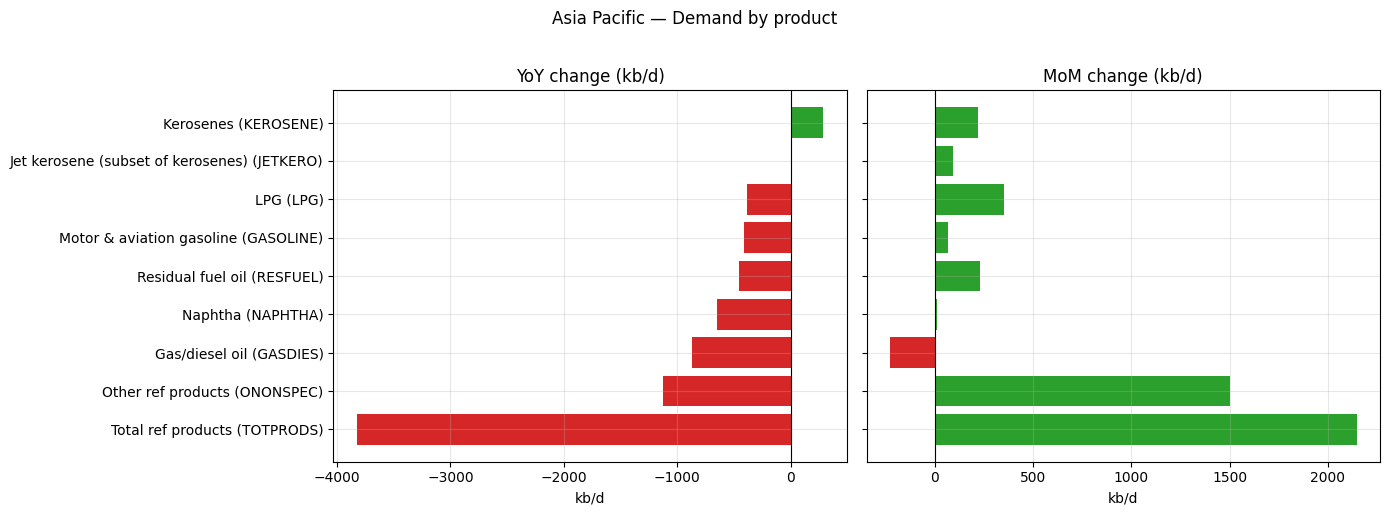

### Ending stocks — regional summary (mbbl)

,product,month,level_kb_d,yoy_change,yoy_pct,mom_change,mom_pct,vs_5y_range,panel_n,excluded_n
0,Total ref products (TOTPRODS),2026-07,280.0,-1.0,-0.4,-11.0,-3.7,44% of 5y range,10,21
1,Gas/diesel oil (GASDIES),2026-07,70.0,1.0,1.8,-7.0,-8.8,Above 5y high,10,21
2,Jet kerosene (subset of kerosenes) (JETKERO),2026-07,22.0,-1.0,-4.0,-2.0,-9.4,Below 5y low,9,22
3,Kerosenes (KEROSENE),2026-07,41.0,-3.0,-5.8,-1.0,-3.3,Below 5y low,10,21
4,LPG (LPG),2026-07,53.0,-0.0,-0.7,0.0,0.6,Below 5y low,9,22
5,Motor & aviation gasoline (GASOLINE),2026-07,43.0,3.0,7.6,0.0,0.2,Above 5y high,10,21
6,Naphtha (NAPHTHA),2026-07,30.0,1.0,3.4,-2.0,-5.4,Above 5y high,8,23
7,Other ref products (ONONSPEC),2026-07,15.0,-0.0,-1.8,-1.0,-4.4,Below 5y low,8,23
8,Residual fuel oil (RESFUEL),2026-07,28.0,-1.0,-4.9,-1.0,-1.8,Below 5y low,10,21


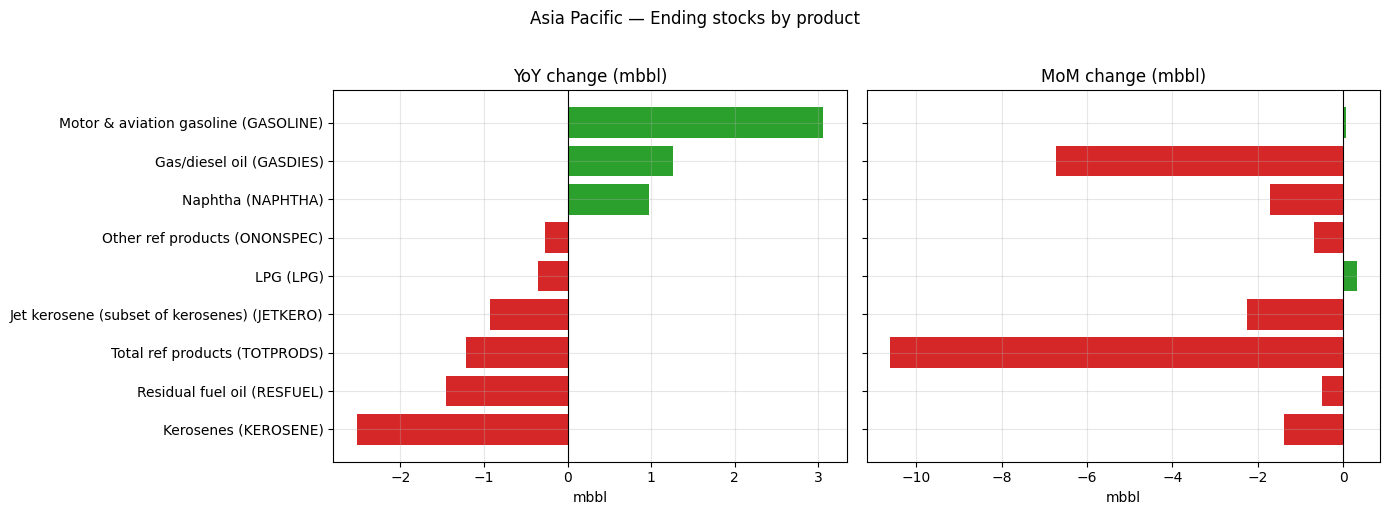

In [4]:
for metric in METRICS:
    unit = METRIC_UNITS[metric]
    regional_summary = by_metric[metric]["summary"]
    display(Markdown(f"### {METRIC_LABELS[metric]} — regional summary ({unit})"))

    cols = [
        "product", "month", "level_kb_d", "yoy_change", "yoy_pct",
        "mom_change", "mom_pct", "vs_5y_range", "panel_n", "excluded_n",
    ]
    regional_view = regional_summary[cols].copy()
    regional_view["level_kb_d"] = regional_view["level_kb_d"].round(0)
    regional_view["yoy_change"] = regional_view["yoy_change"].round(0)
    regional_view["mom_change"] = regional_view["mom_change"].round(0)
    regional_view["yoy_pct"] = regional_view["yoy_pct"].round(1)
    regional_view["mom_pct"] = regional_view["mom_pct"].round(1)
    display(regional_view)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    for ax, col, title in zip(
        axes,
        ["yoy_change", "mom_change"],
        [f"YoY change ({unit})", f"MoM change ({unit})"],
    ):
        plot_df = regional_summary.sort_values(col)
        colors = [NEG if v < 0 else POS for v in plot_df[col]]
        ax.barh(plot_df["product"], plot_df[col], color=colors)
        ax.axvline(0, color="black", linewidth=0.8)
        ax.set_title(title)
        ax.set_xlabel(unit)
    fig.suptitle(f"{GEO_LABEL} — {METRIC_LABELS[metric]} by product", y=1.02)
    fig.tight_layout()
    plt.show()



## 4. TOTPRODS — country contributions


### Demand — Total ref products (TOTPRODS) (12 panel countries, ref 2026-07, peer 2026-07)

,country,level_kb_d,yoy_change,mom_change,yoy_share_pct,mom_share_pct
0,China,13389.0,-2862.0,1671.0,75.0,78.0
1,Korea (the Republic of),2657.0,-362.0,134.0,9.0,6.0
2,Philippines (the),0.0,-234.0,0.0,6.0,0.0
3,Indonesia,1980.0,-172.0,151.0,4.0,7.0
4,Japan,2921.0,-74.0,182.0,2.0,8.0
5,Taiwan (Province of China),751.0,-72.0,5.0,2.0,0.0
6,Hong Kong,282.0,-31.0,6.0,1.0,0.0
7,Australia,1092.0,-23.0,-13.0,1.0,-1.0
8,Papua New Guinea,8.0,-1.0,0.0,0.0,0.0
9,Thailand,1120.0,1.0,7.0,-0.0,0.0


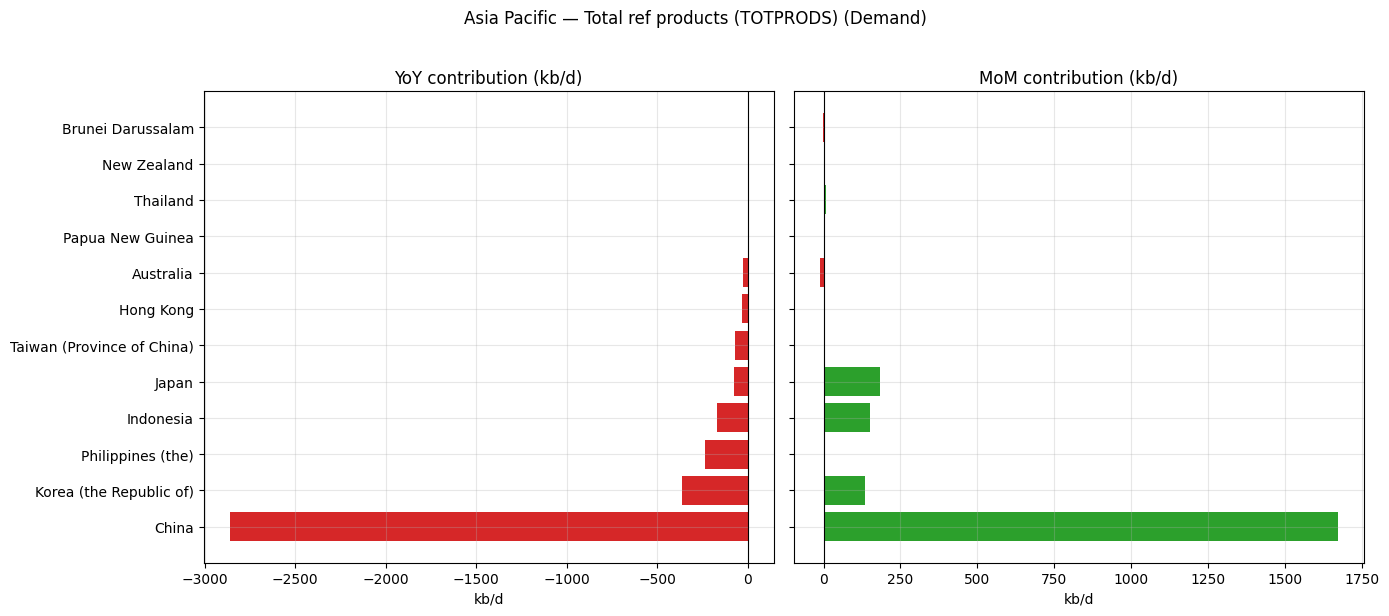

### Ending stocks — Total ref products (TOTPRODS) (10 panel countries, ref 2026-07, peer 2026-07)

,country,level_kb_d,yoy_change,mom_change,yoy_share_pct,mom_share_pct
0,Korea (the Republic of),69.0,-5.0,-3.0,400.0,32.0
1,Philippines (the),0.0,-2.0,0.0,159.0,-0.0
2,Hong Kong,6.0,-1.0,1.0,52.0,-7.0
3,Japan,107.0,-0.0,-1.0,18.0,10.0
4,Brunei Darussalam,0.0,0.0,0.0,-4.0,-0.0
5,Papua New Guinea,0.0,0.0,-0.0,-6.0,0.0
6,New Zealand,6.0,0.0,-0.0,-37.0,1.0
7,Thailand,23.0,0.0,-3.0,-40.0,29.0
8,Taiwan (Province of China),34.0,2.0,-1.0,-185.0,13.0
9,Australia,36.0,3.0,-2.0,-258.0,21.0


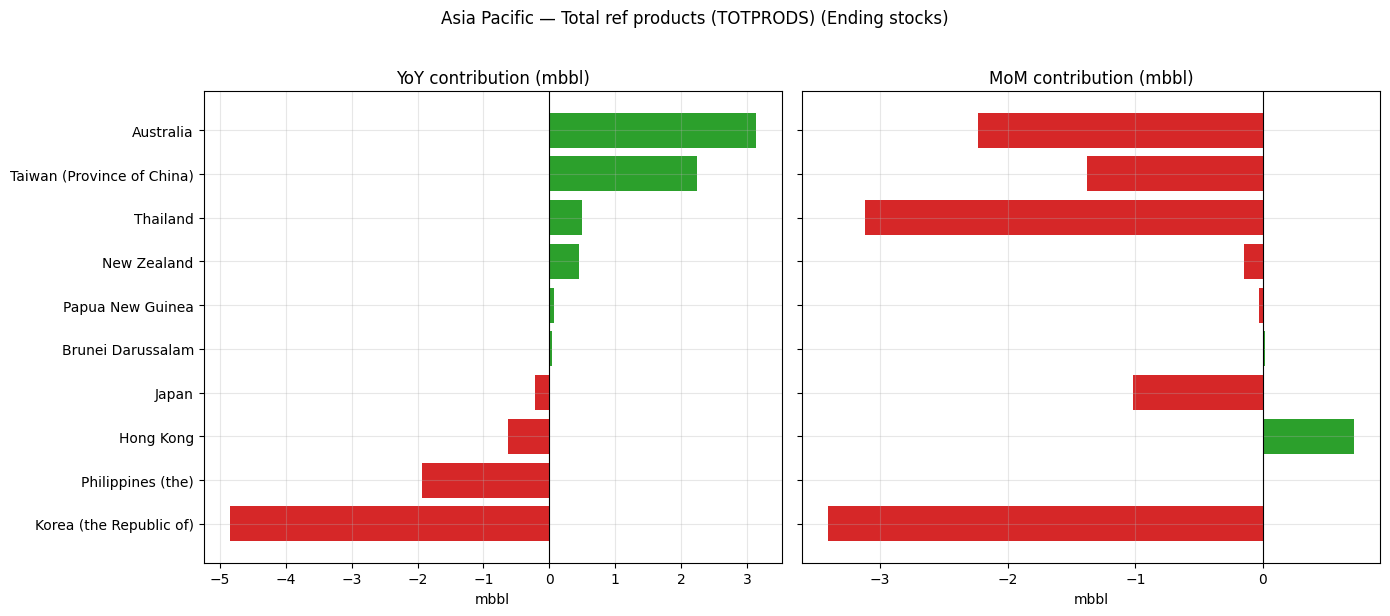

In [5]:
for metric in METRICS:
    unit = METRIC_UNITS[metric]
    contrib = by_metric[metric]["contrib"]
    ref_month = by_metric[metric]["ref_month"]
    peer_month = by_metric[metric]["peer_month"]

    display(Markdown(
        f"### {METRIC_LABELS[metric]} — {product_label(PRODUCT)} "
        f"({len(contrib)} panel countries, ref {ref_month}, peer {peer_month})"
    ))

    if contrib.empty:
        print("No balanced panel for this product.")
        continue

    country_view = contrib[
        ["country", "level_kb_d", "yoy_change", "mom_change", "yoy_share_pct", "mom_share_pct"]
    ].sort_values("yoy_change").copy()
    for c in ["level_kb_d", "yoy_change", "mom_change"]:
        country_view[c] = country_view[c].round(0)
    for c in ["yoy_share_pct", "mom_share_pct"]:
        country_view[c] = country_view[c].round(0)
    display(country_view)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    plot_df = contrib.sort_values("yoy_change")
    for ax, col, title in zip(
        axes,
        ["yoy_change", "mom_change"],
        [f"YoY contribution ({unit})", f"MoM contribution ({unit})"],
    ):
        colors = [NEG if v < 0 else POS for v in plot_df[col]]
        ax.barh(plot_df["country"], plot_df[col], color=colors)
        ax.axvline(0, color="black", linewidth=0.8)
        ax.set_title(title)
        ax.set_xlabel(unit)
    fig.suptitle(
        f"{GEO_LABEL} — {product_label(PRODUCT)} ({METRIC_LABELS[metric]})",
        y=1.02,
    )
    fig.tight_layout()
    plt.show()



## 5. All products — country tables


In [6]:
for metric in METRICS:
    unit = METRIC_UNITS[metric]
    regional_summary = by_metric[metric]["summary"]
    display(Markdown(f"### {METRIC_LABELS[metric]} — country tables ({unit})"))

    for code in regional_summary["product_code"]:
        tbl = build_country_contribution_table(
            GEOGRAPHY, code, lag_months=DRIVER_LAG_MONTHS, metric=metric,
        )
        ref = regional_summary.loc[regional_summary["product_code"] == code, "month"].iloc[0]
        print(f"\n{product_label(code)} — ref {ref} — {len(tbl)} countries")
        if tbl.empty:
            print("  (no balanced panel)")
            continue
        show = tbl[["country", "yoy_change", "mom_change", "yoy_share_pct"]].sort_values(
            "yoy_change", ascending=False,
        )
        display(show.round(0))



### Demand — country tables (kb/d)


Total ref products (TOTPRODS) — ref 2026-07 — 12 countries


,country,yoy_change,mom_change,yoy_share_pct
11,Brunei Darussalam,1.0,-1.0,-0.0
10,New Zealand,1.0,6.0,-0.0
9,Thailand,1.0,7.0,-0.0
8,Papua New Guinea,-1.0,0.0,0.0
7,Australia,-23.0,-13.0,1.0
6,Hong Kong,-31.0,6.0,1.0
5,Taiwan (Province of China),-72.0,5.0,2.0
4,Japan,-74.0,182.0,2.0
3,Indonesia,-172.0,151.0,4.0
2,Philippines (the),-234.0,0.0,6.0



Gas/diesel oil (GASDIES) — ref 2026-07 — 11 countries


,country,yoy_change,mom_change,yoy_share_pct
10,Taiwan (Province of China),10.0,15.0,-1.0
9,Australia,4.0,-17.0,-0.0
8,Thailand,2.0,-5.0,-0.0
7,Brunei Darussalam,1.0,-1.0,-0.0
6,Papua New Guinea,0.0,-0.0,-0.0
5,New Zealand,-0.0,2.0,0.0
4,Korea (the Republic of),-13.0,31.0,2.0
3,Japan,-18.0,26.0,2.0
2,Hong Kong,-19.0,-11.0,2.0
1,Indonesia,-310.0,-362.0,36.0


...

,country,yoy_change,mom_change,yoy_share_pct
7,Taiwan (Province of China),1.0,-0.0,78.0
6,Japan,1.0,-0.0,64.0
5,Korea (the Republic of),0.0,0.0,9.0
1,Indonesia,0.0,0.0,0.0
2,New Zealand,0.0,0.0,0.0
3,Brunei Darussalam,0.0,0.0,0.0
4,Australia,0.0,0.0,0.0
0,Thailand,-0.0,-1.0,-51.0



Other ref products (ONONSPEC) — ref 2026-07 — 8 countries


,country,yoy_change,mom_change,yoy_share_pct
7,Korea (the Republic of),0.0,-0.0,-156.0
6,New Zealand,0.0,0.0,-19.0
5,Papua New Guinea,0.0,0.0,-0.0
3,Indonesia,0.0,0.0,-0.0
4,Brunei Darussalam,0.0,-0.0,-0.0
2,Thailand,-0.0,-0.0,35.0
1,Japan,-0.0,-0.0,58.0
0,Australia,-0.0,-0.0,181.0



Residual fuel oil (RESFUEL) — ref 2026-07 — 10 countries


,country,yoy_change,mom_change,yoy_share_pct
9,New Zealand,0.0,0.0,-5.0
8,Japan,0.0,-1.0,-2.0
6,Papua New Guinea,0.0,-0.0,-0.0
7,Indonesia,0.0,0.0,-0.0
5,Brunei Darussalam,0.0,0.0,-0.0
4,Australia,-0.0,0.0,2.0
3,Thailand,-0.0,0.0,4.0
2,Taiwan (Province of China),-0.0,0.0,22.0
1,Hong Kong,-0.0,0.0,22.0
0,Korea (the Republic of),-1.0,-1.0,56.0


## 6. Panel audit (TOTPRODS)


In [7]:
for metric in METRICS:
    audit = by_metric[metric]["audit"].sort_values(
        ["in_panel", "flag_lagging", "months_behind_peer"],
        ascending=[False, True, False],
    )
    display(Markdown(f"### {METRIC_LABELS[metric]} — panel audit (TOTPRODS)"))
    display(
        audit[
            ["country", "latest_month", "months_behind_peer", "flag_lagging", "in_panel"]
        ].round({"months_behind_peer": 0})
    )



### Demand — panel audit (TOTPRODS)

,country,latest_month,months_behind_peer,flag_lagging,in_panel
19,Australia,2026-07,0,False,True
20,Brunei Darussalam,2026-07,0,False,True
21,China,2026-07,0,False,True
22,Hong Kong,2026-07,0,False,True
23,Indonesia,2026-07,0,False,True
24,Japan,2026-07,0,False,True
25,Korea (the Republic of),2026-07,0,False,True
26,New Zealand,2026-07,0,False,True
27,Papua New Guinea,2026-07,0,False,True
28,Philippines (the),2026-07,0,False,True


### Ending stocks — panel audit (TOTPRODS)

,country,latest_month,months_behind_peer,flag_lagging,in_panel
21,Australia,2026-07,0,False,True
22,Brunei Darussalam,2026-07,0,False,True
23,Hong Kong,2026-07,0,False,True
24,Japan,2026-07,0,False,True
25,Korea (the Republic of),2026-07,0,False,True
26,New Zealand,2026-07,0,False,True
27,Papua New Guinea,2026-07,0,False,True
28,Philippines (the),2026-07,0,False,True
29,Thailand,2026-07,0,False,True
30,Taiwan (Province of China),2026-07,0,False,True


## 7. Visual summary


### Demand — visual summary

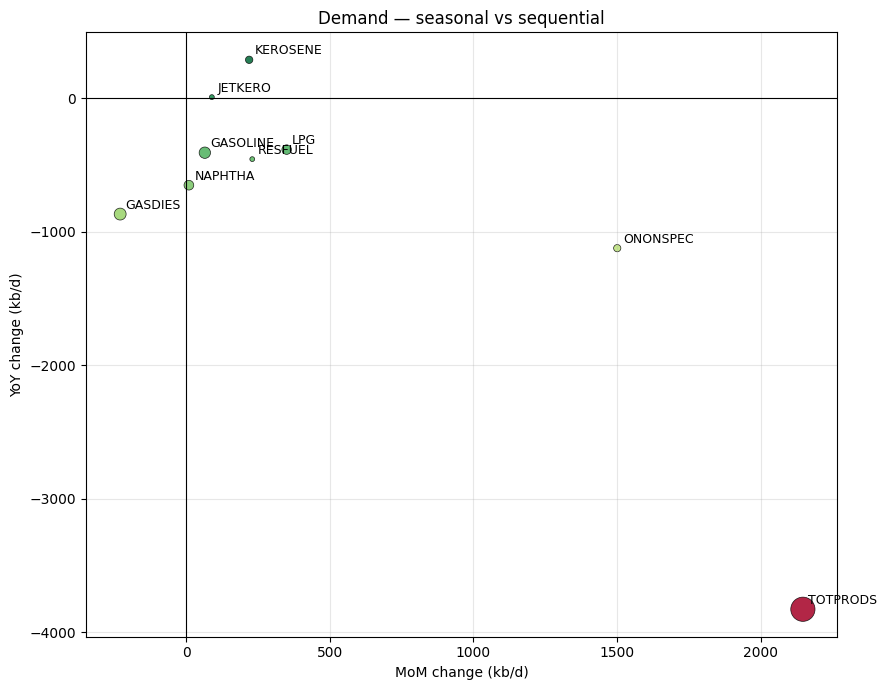

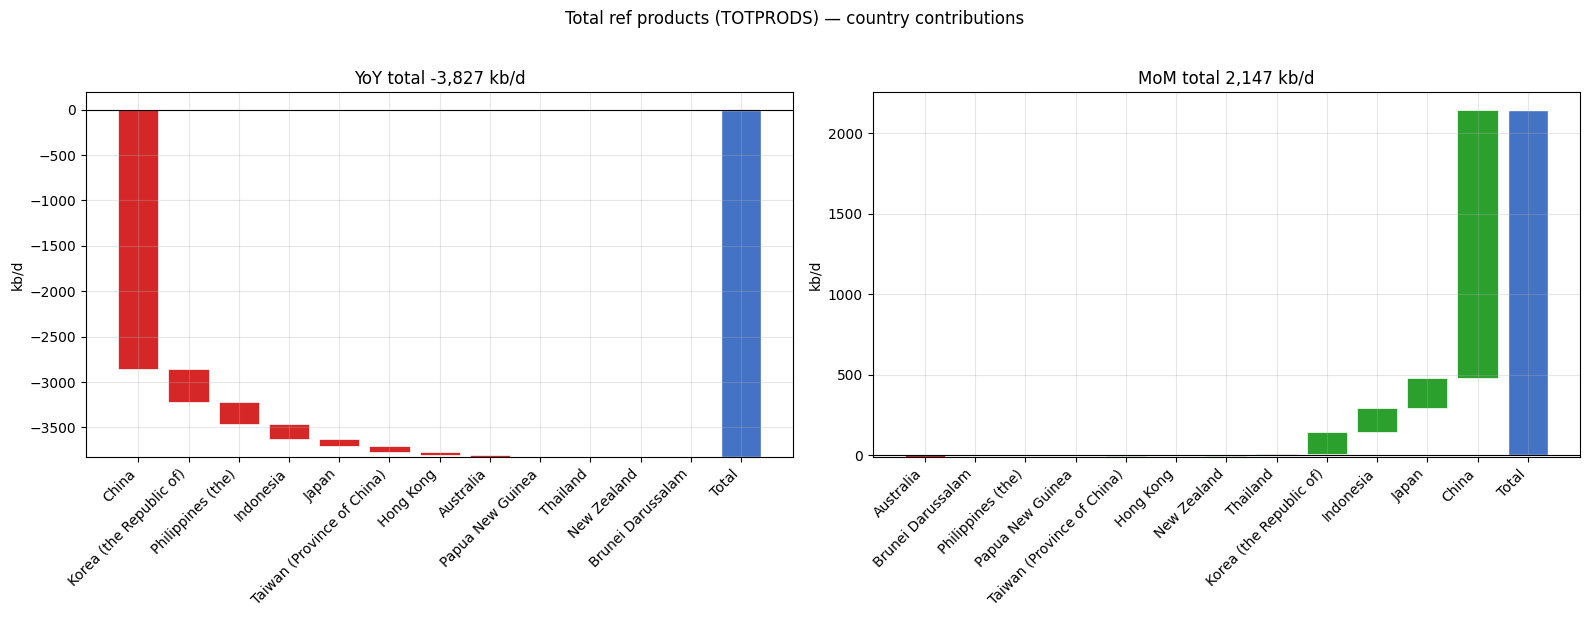

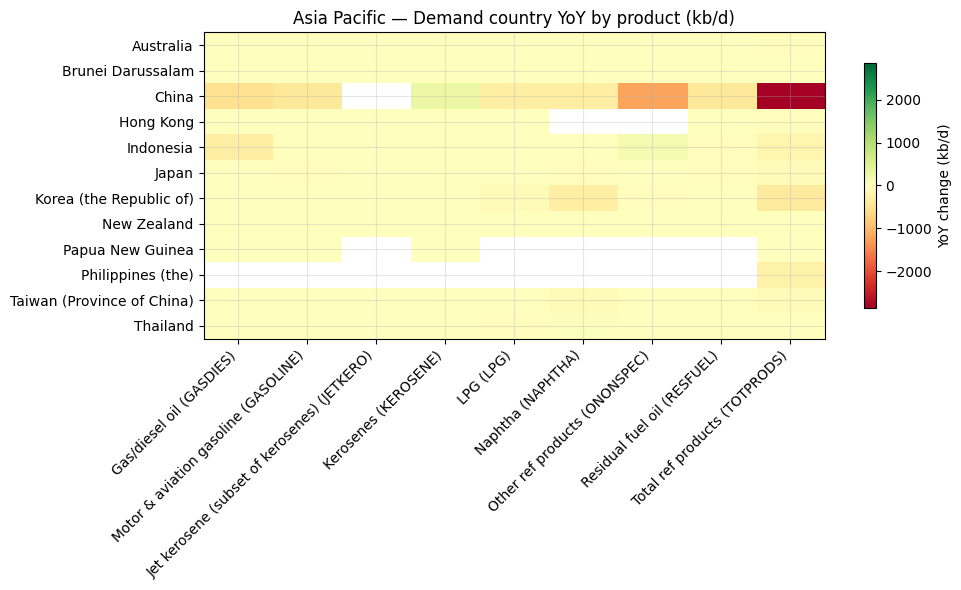

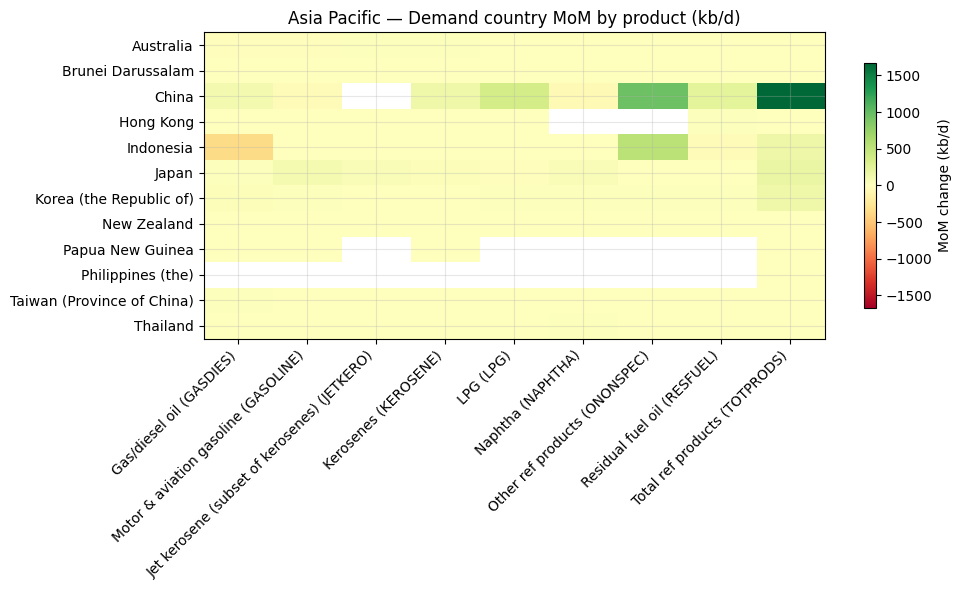

### Ending stocks — visual summary

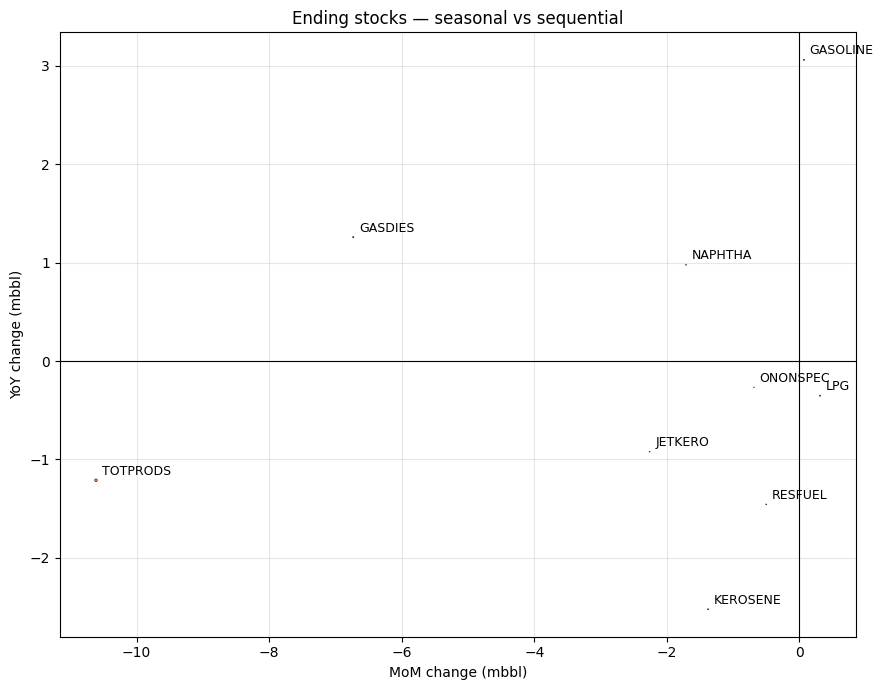

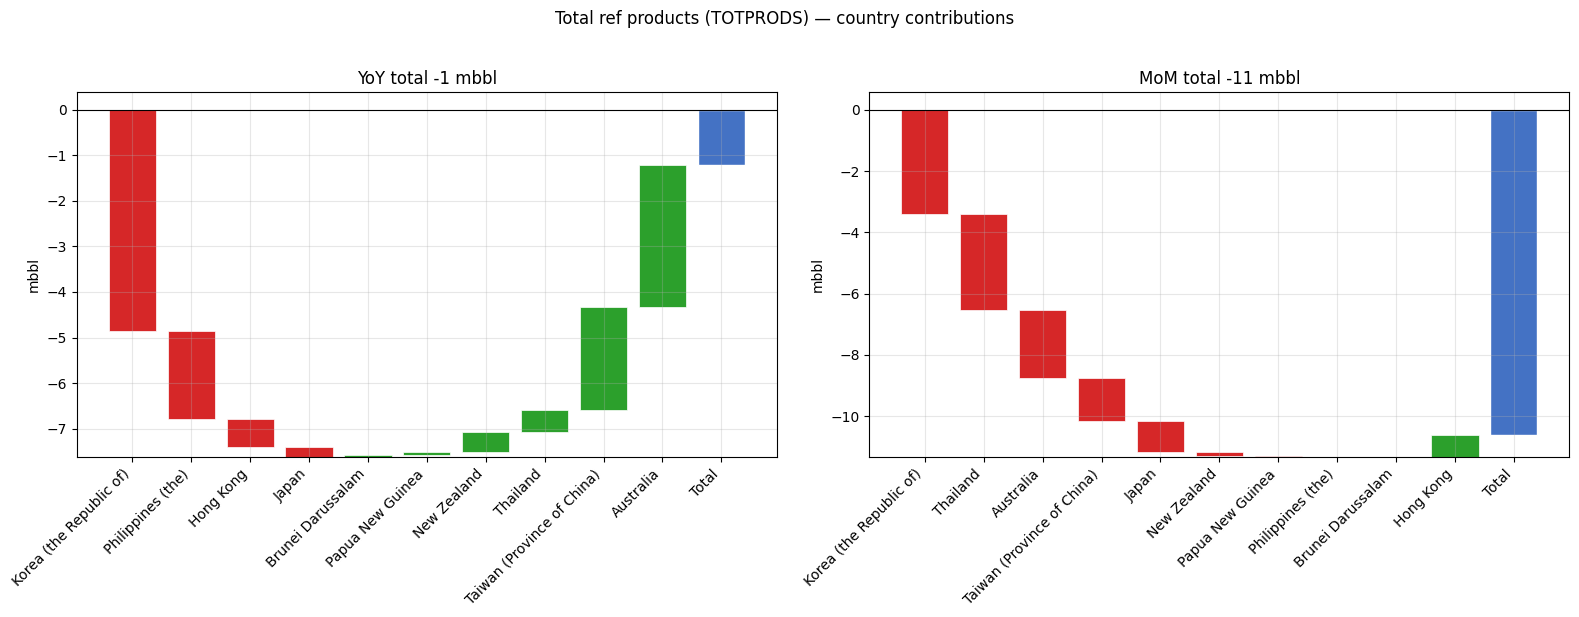

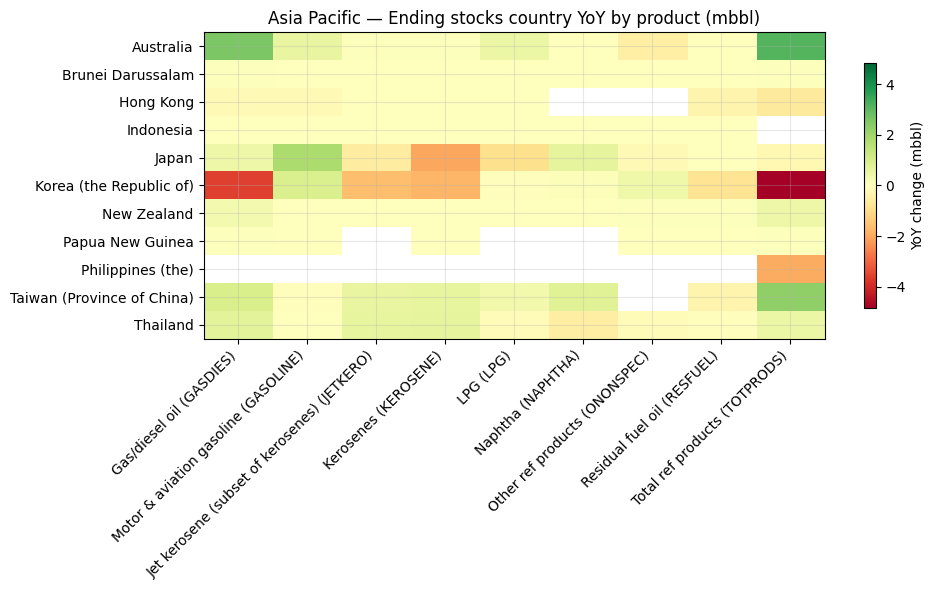

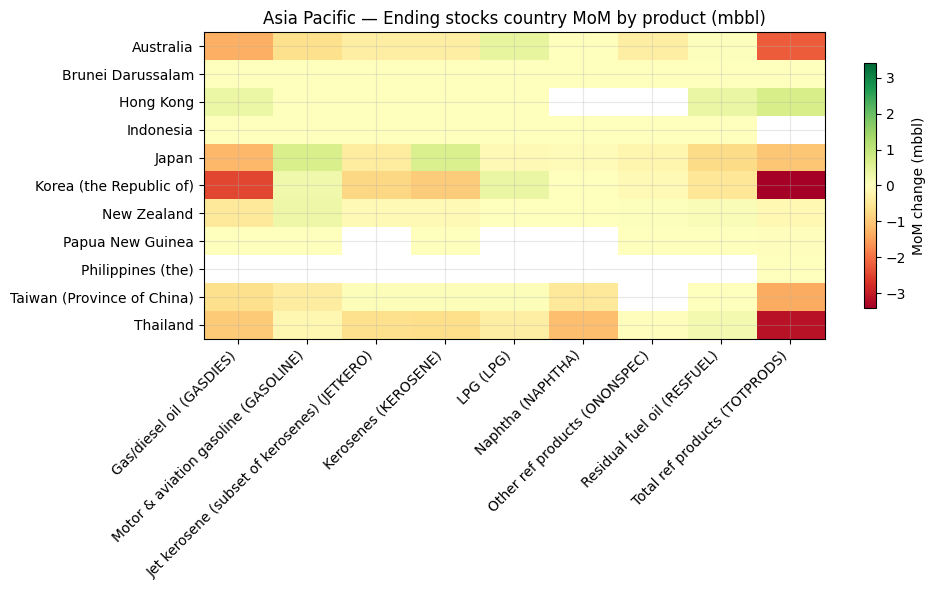

In [8]:
for metric in METRICS:
    unit = METRIC_UNITS[metric]
    regional_summary = by_metric[metric]["summary"]
    contrib = by_metric[metric]["contrib"]
    display(Markdown(f"### {METRIC_LABELS[metric]} — visual summary"))

    fig, ax = plt.subplots(figsize=(9, 7))
    sizes = regional_summary["level_kb_d"].clip(lower=1) / 80
    ax.scatter(
        regional_summary["mom_change"],
        regional_summary["yoy_change"],
        s=sizes,
        c=regional_summary["yoy_change"],
        cmap="RdYlGn",
        alpha=0.85,
        edgecolors="black",
        linewidths=0.5,
    )
    for _, row in regional_summary.iterrows():
        ax.annotate(
            row["product_code"],
            (row["mom_change"], row["yoy_change"]),
            textcoords="offset points",
            xytext=(4, 4),
            fontsize=9,
        )
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel(f"MoM change ({unit})")
    ax.set_ylabel(f"YoY change ({unit})")
    ax.set_title(f"{METRIC_LABELS[metric]} — seasonal vs sequential")
    plt.tight_layout()
    plt.show()

    if not contrib.empty:
        wf_yoy = contrib.sort_values("yoy_change")
        wf_mom = contrib.sort_values("mom_change")
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        plot_waterfall(
            axes[0],
            wf_yoy["country"].tolist(),
            wf_yoy["yoy_change"].tolist(),
            f"YoY total {wf_yoy['yoy_change'].sum():,.0f} {unit}",
        )
        plot_waterfall(
            axes[1],
            wf_mom["country"].tolist(),
            wf_mom["mom_change"].tolist(),
            f"MoM total {wf_mom['mom_change'].sum():,.0f} {unit}",
        )
        for ax in axes:
            ax.set_ylabel(unit)
        fig.suptitle(f"{product_label(PRODUCT)} — country contributions", y=1.02)
        fig.tight_layout()
        plt.show()

    for value_col, chg_label in [("yoy_change", "YoY"), ("mom_change", "MoM")]:
        matrix = country_contrib_matrix(
            regional_summary, GEOGRAPHY, DRIVER_LAG_MONTHS, metric, value_col=value_col,
        )
        if matrix.empty:
            continue
        plot_country_product_heatmap(
            matrix,
            f"{GEO_LABEL} — {METRIC_LABELS[metric]} country {chg_label} by product ({unit})",
            f"{chg_label} change ({unit})",
        )



## 8. Level & share context


### Demand — level & share context

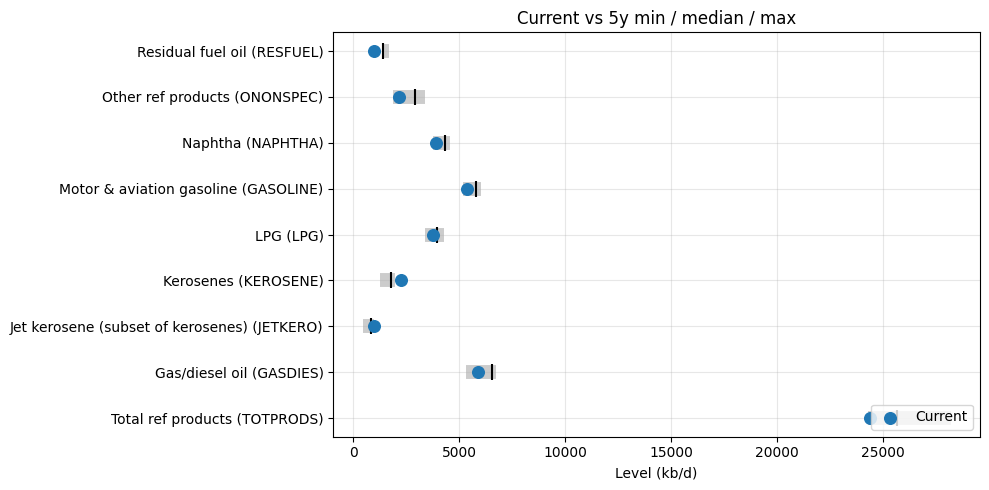

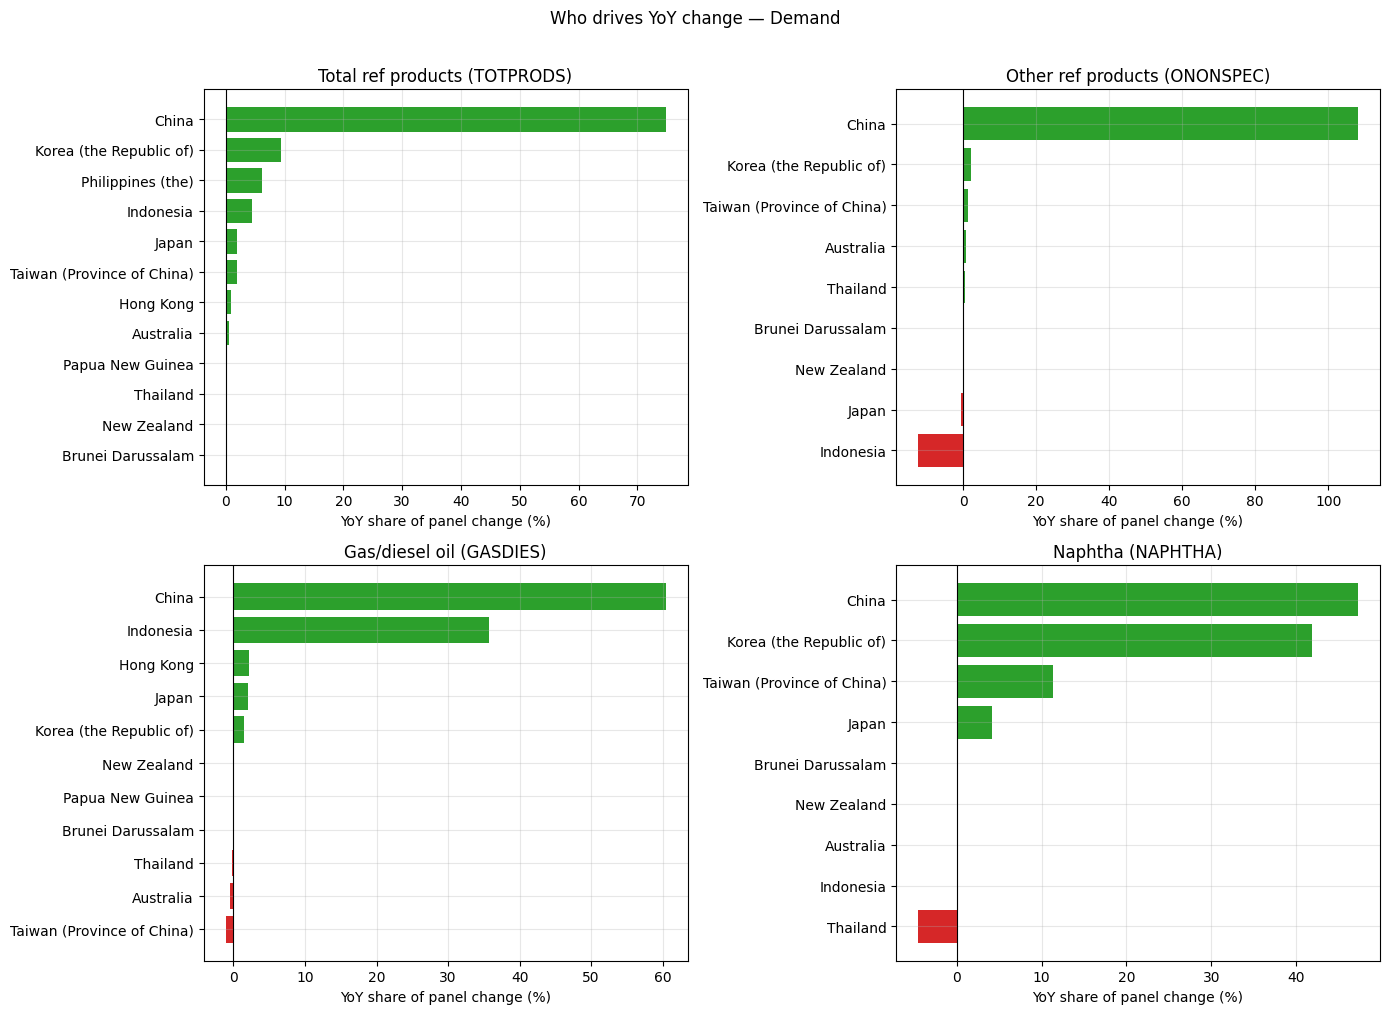

### Ending stocks — level & share context

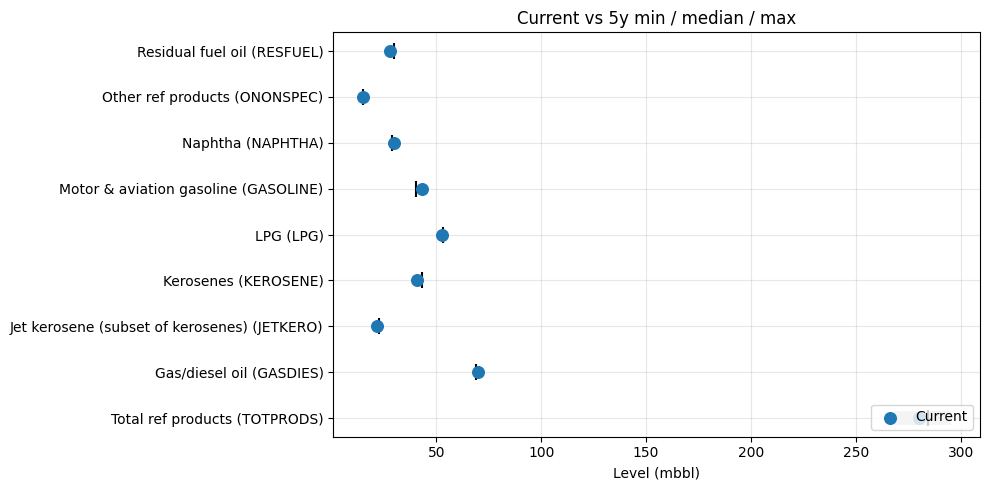

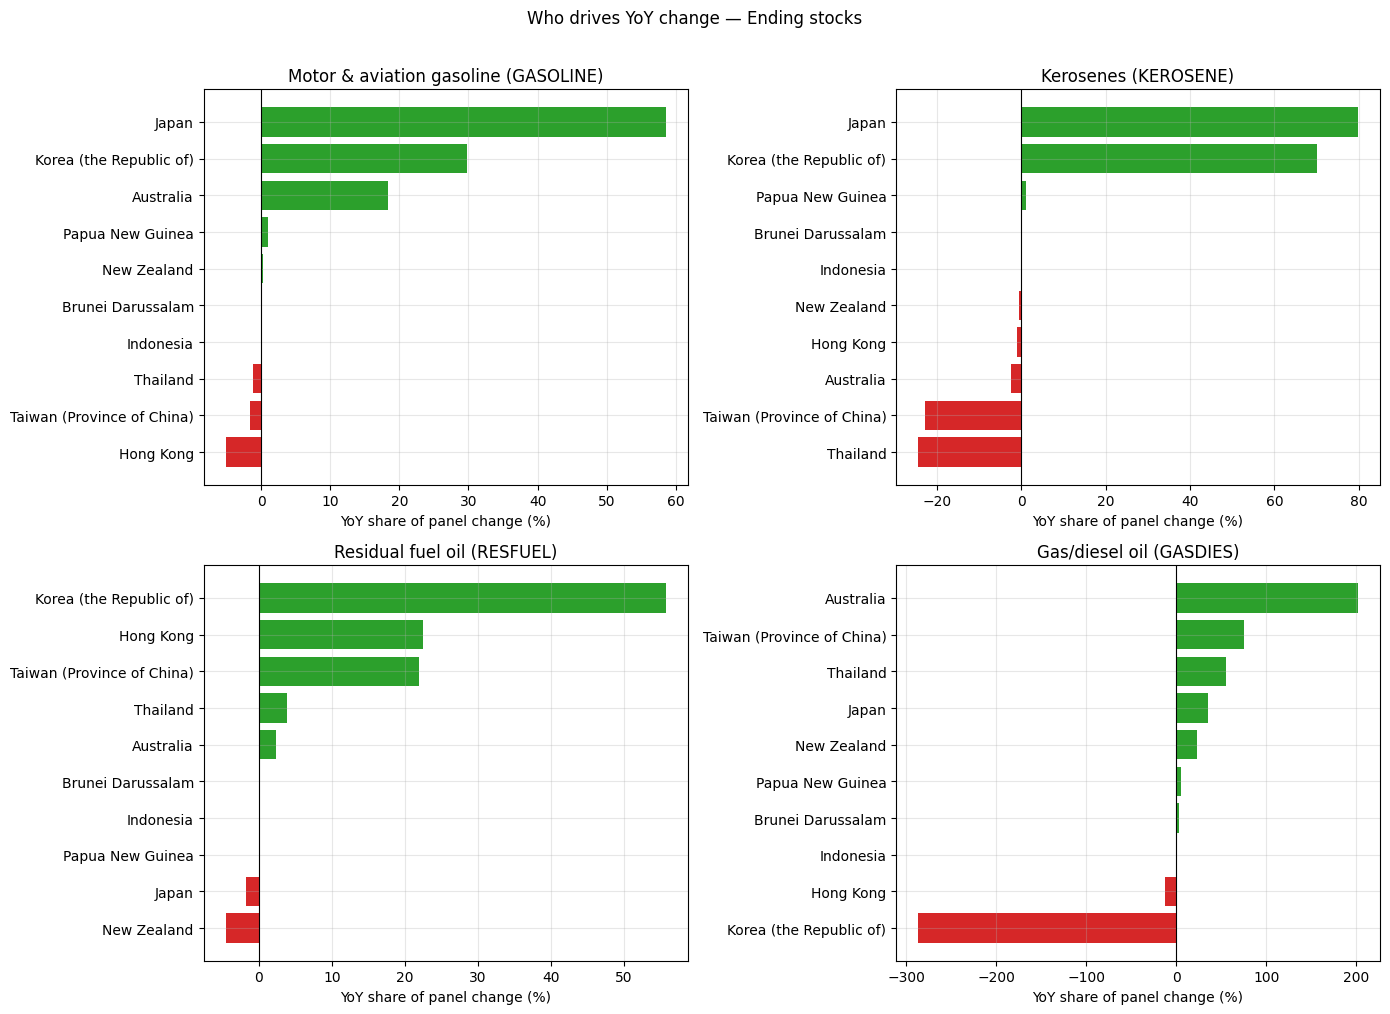

In [9]:
for metric in METRICS:
    unit = METRIC_UNITS[metric]
    regional_summary = by_metric[metric]["summary"]
    display(Markdown(f"### {METRIC_LABELS[metric]} — level & share context"))

    band = regional_summary.reset_index(drop=True)
    y = np.arange(len(band))
    fig, ax = plt.subplots(figsize=(10, max(5, len(band) * 0.45)))
    for i, row in band.iterrows():
        ax.hlines(i, row["hist_5y_min"], row["hist_5y_max"], color="#cccccc", linewidth=10, zorder=1)
        ax.scatter(row["hist_5y_median"], i, marker="|", color="black", s=120, zorder=2)
        ax.scatter(row["level_kb_d"], i, color="#1f77b4", s=70, zorder=3, label="Current" if i == 0 else "")
    ax.set_yticks(y)
    ax.set_yticklabels(band["product"])
    ax.set_xlabel(f"Level ({unit})")
    ax.set_title(f"Current vs 5y min / median / max")
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

    top_codes = (
        regional_summary.assign(_abs=regional_summary["yoy_change"].abs())
        .nlargest(4, "_abs")["product_code"]
        .tolist()
    )
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    for ax, code in zip(axes.flat, top_codes):
        tbl = build_country_contribution_table(
            GEOGRAPHY, code, lag_months=DRIVER_LAG_MONTHS, metric=metric,
        )
        if tbl.empty:
            ax.set_visible(False)
            continue
        tbl = tbl.sort_values("yoy_share_pct")
        colors = [NEG if v < 0 else POS for v in tbl["yoy_share_pct"]]
        ax.barh(tbl["country"], tbl["yoy_share_pct"], color=colors)
        ax.axvline(0, color="black", linewidth=0.8)
        ax.set_xlabel("YoY share of panel change (%)")
        ax.set_title(product_label(code))
    fig.suptitle(f"Who drives YoY change — {METRIC_LABELS[metric]}", y=1.01)
    fig.tight_layout()
    plt.show()



## 9. Freshness & trends


### Demand — freshness & trends

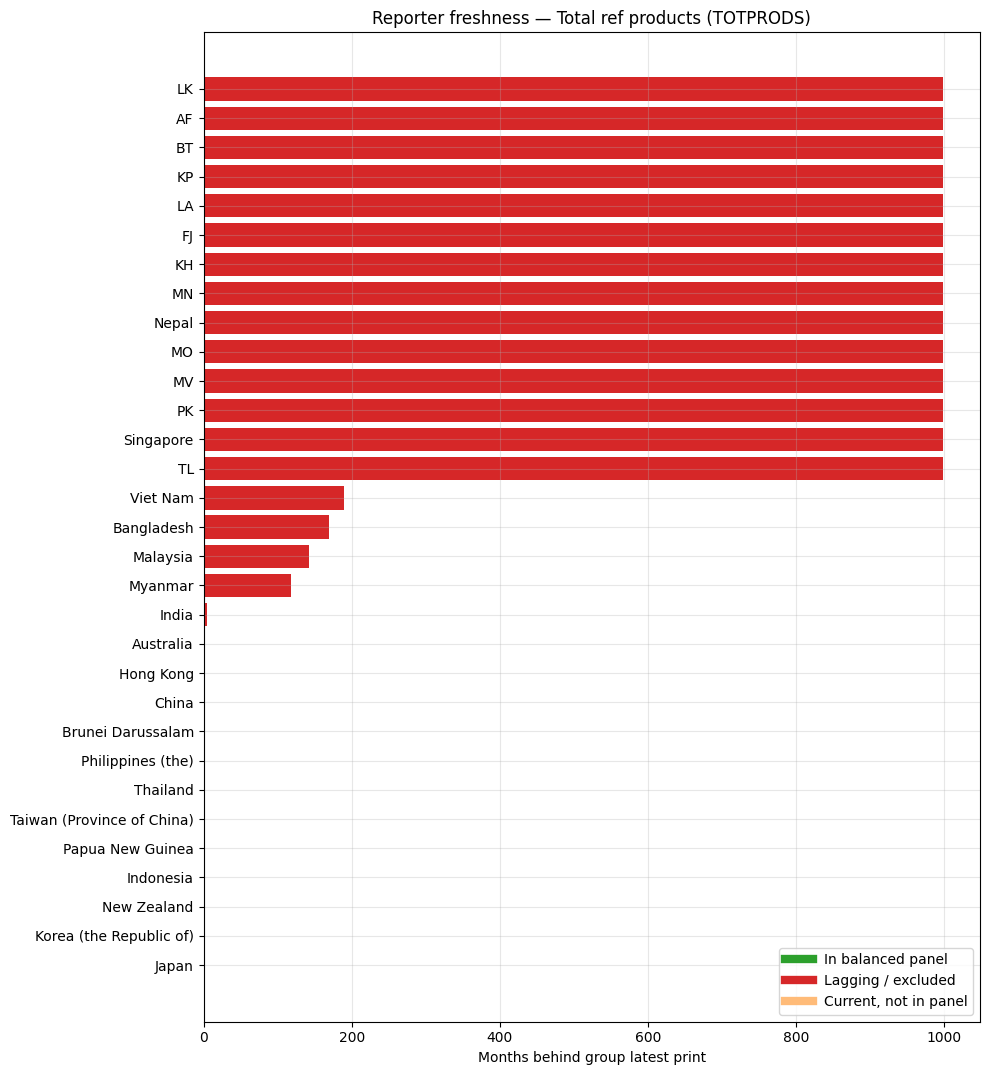

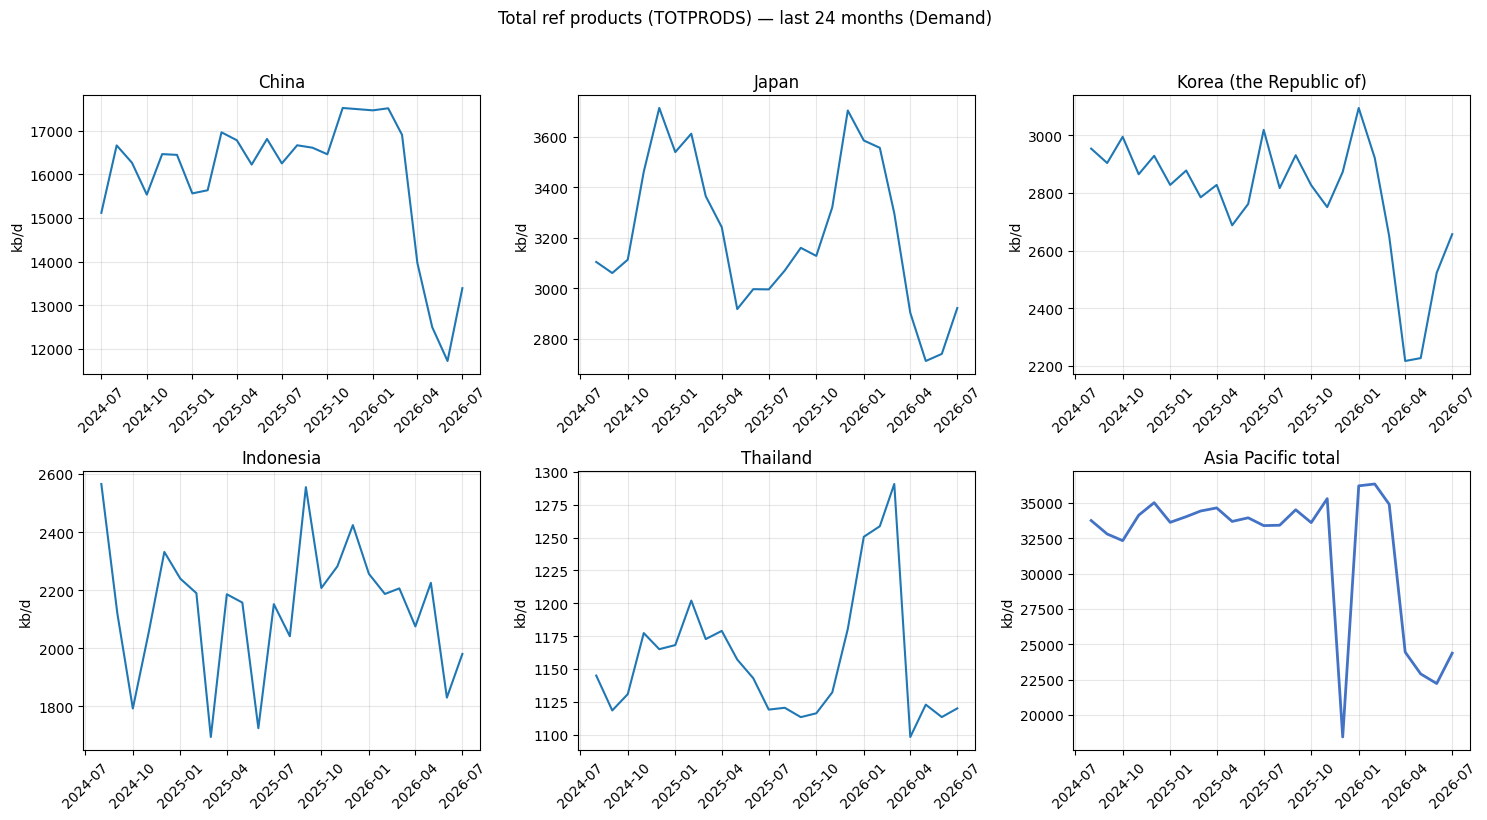

### Ending stocks — freshness & trends

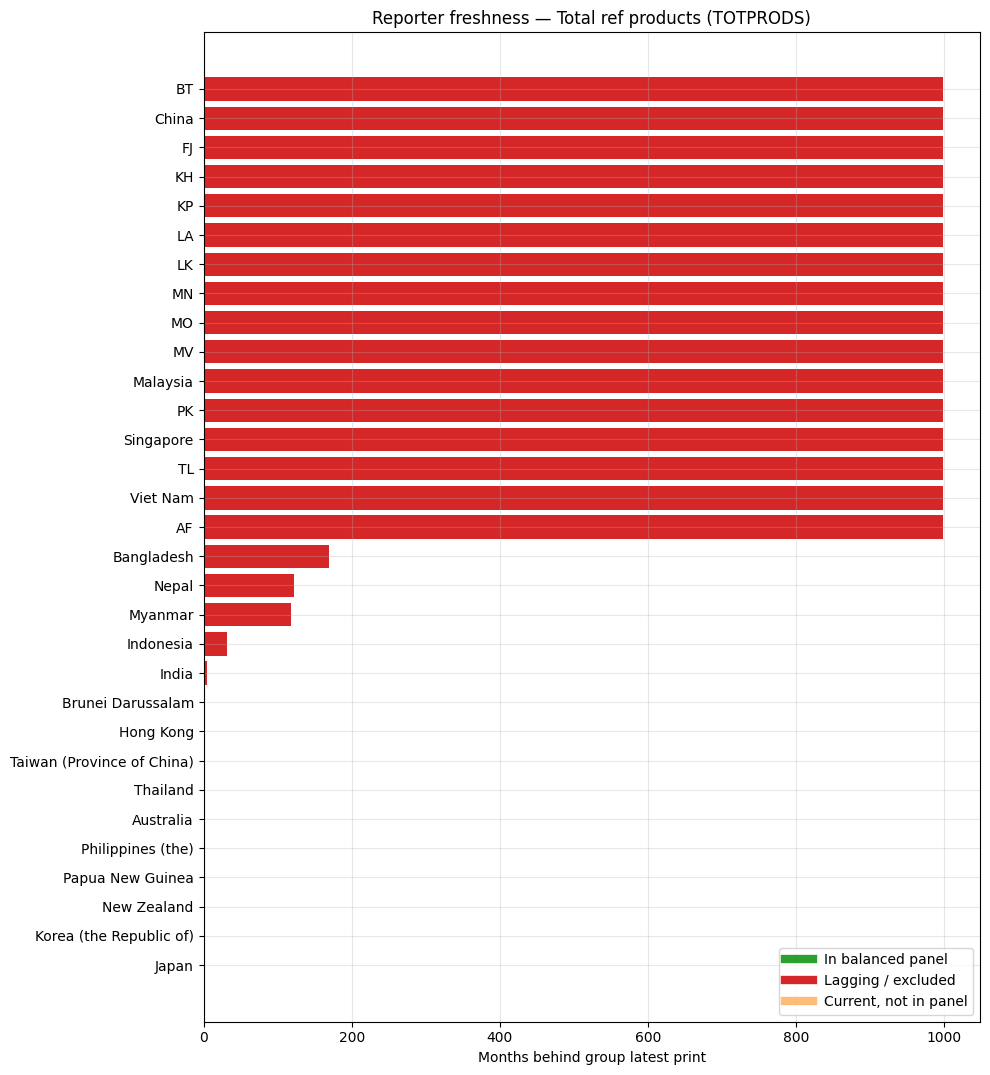

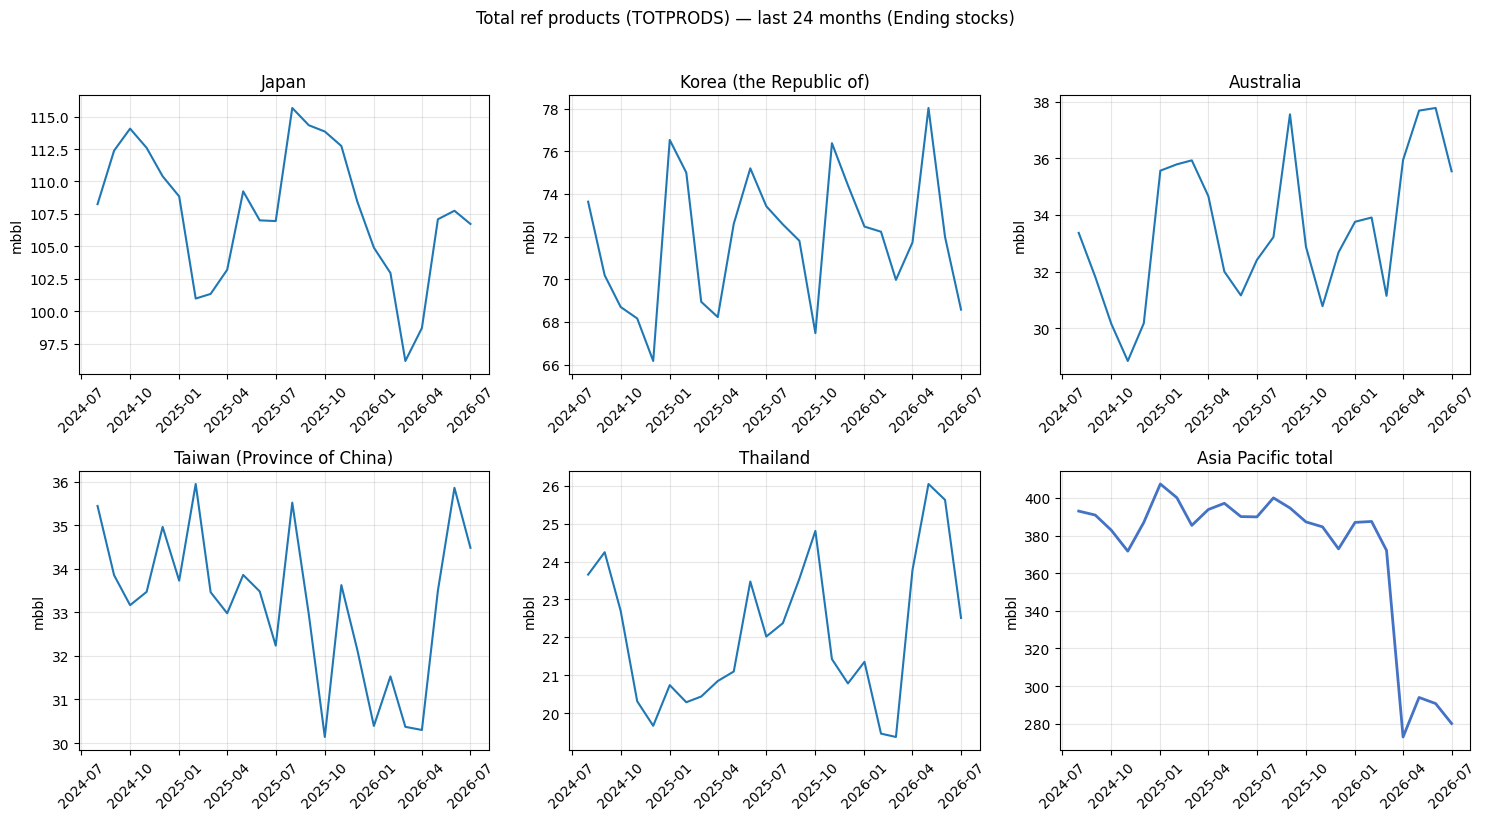

In [10]:
for metric in METRICS:
    unit = METRIC_UNITS[metric]
    contrib = by_metric[metric]["contrib"]
    audit = by_metric[metric]["audit"]
    display(Markdown(f"### {METRIC_LABELS[metric]} — freshness & trends"))

    audit_plot = audit.sort_values("months_behind_peer", ascending=True)
    bar_colors = [
        POS if r.in_panel else (NEG if r.flag_lagging else "#ffbb78")
        for r in audit_plot.itertuples()
    ]
    fig, ax = plt.subplots(figsize=(10, max(5, len(audit_plot) * 0.35)))
    ax.barh(audit_plot["country"], audit_plot["months_behind_peer"], color=bar_colors)
    ax.set_xlabel("Months behind group latest print")
    ax.set_title(f"Reporter freshness — {product_label(PRODUCT)}")
    ax.legend(
        handles=[
            plt.Line2D([0], [0], color=POS, lw=6, label="In balanced panel"),
            plt.Line2D([0], [0], color=NEG, lw=6, label="Lagging / excluded"),
            plt.Line2D([0], [0], color="#ffbb78", lw=6, label="Current, not in panel"),
        ],
        loc="lower right",
    )
    plt.tight_layout()
    plt.show()

    if contrib.empty:
        continue

    top5 = contrib.nlargest(5, "level_kb_d")
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    for ax, (_, row) in zip(axes.flat, top5.iterrows()):
        iso = str(row["ref_area"])
        ts = get_dashboard_series(
            PRODUCT, iso, metric, lag_months=DRIVER_LAG_MONTHS,
        ).tail(24)
        ax.plot(ts["date"], ts["value"], color="#1f77b4")
        ax.set_title(row["country"])
        ax.set_ylabel(unit)
        ax.tick_params(axis="x", rotation=45)

    regional_ts = get_dashboard_series(
        PRODUCT, GEOGRAPHY, metric, lag_months=DRIVER_LAG_MONTHS,
    ).tail(24)
    axes.flat[5].plot(regional_ts["date"], regional_ts["value"], color=TOTAL, linewidth=2)
    axes.flat[5].set_title(f"{GEO_LABEL} total")
    axes.flat[5].set_ylabel(unit)
    axes.flat[5].tick_params(axis="x", rotation=45)

    fig.suptitle(f"{product_label(PRODUCT)} — last 24 months ({METRIC_LABELS[metric]})", y=1.02)
    fig.tight_layout()
    plt.show()



## 10. Country drill-down

After spotting a driver in the heatmap or TOTPRODS table, set **`DRILL_COUNTRIES`** (e.g. `['GB']`) or leave `None` to auto-pick the top `DRILL_AUTO_N` |YoY| movers.


In [ ]:
# --- drill-down config (set after reviewing Sections 3–9) ---
# ISO codes (UK → GB). None = auto-pick largest |YoY| movers on TOTPRODS demand.
DRILL_COUNTRIES: list[str] | None = ["GB", "DE", "FR", "NL", "ES"]#None  # e.g. ["GB", "DE"]
DRILL_AUTO_N = 3
DRILL_HEADLINE_PRODUCT = "TOTPRODS"


def resolve_drill_countries() -> list[tuple[str, str]]:
    """Return [(ref_area, country_name), ...] to drill into."""
    if DRILL_COUNTRIES:
        codes = [str(GEO_ALIASES.get(c, c)) for c in DRILL_COUNTRIES]
    else:
        contrib = by_metric.get("demand", {}).get("contrib", pd.DataFrame())
        if contrib.empty:
            return []
        n = min(DRILL_AUTO_N, len(contrib))
        top = contrib.loc[contrib["yoy_change"].abs().nlargest(n).index]
        codes = top["ref_area"].astype(str).tolist()
    return [(c, COUNTRY_NAMES.get(c, c)) for c in codes]


drill_targets = resolve_drill_countries()
if not drill_targets:
    print(
        "No drill-down targets — set DRILL_COUNTRIES (e.g. ['GB']) "
        "or ensure regional TOTPRODS panel loaded."
    )
else:
    print("Drill-down:", ", ".join(f"{name} ({code})" for code, name in drill_targets))

for ref_area, country_name in drill_targets:
    display(Markdown(f"# {country_name} ({ref_area})"))

    for metric in METRICS:
        unit = METRIC_UNITS[metric]
        contrib = by_metric[metric]["contrib"]
        display(Markdown(f"## {METRIC_LABELS[metric]} ({unit})"))

        if not contrib.empty:
            match = contrib.loc[contrib["ref_area"].astype(str) == ref_area]
            if not match.empty:
                row = match.iloc[0]
                reg_yoy = contrib["yoy_change"].sum()
                reg_mom = contrib["mom_change"].sum()
                display(Markdown(
                    f"**{product_label(DRILL_HEADLINE_PRODUCT)} vs {GEO_LABEL} panel** — "
                    f"YoY **{row['yoy_change']:,.0f}** {unit} "
                    f"({row['yoy_share_pct']:.0f}% of regional), "
                    f"MoM **{row['mom_change']:,.0f}** {unit} "
                    f"({row['mom_share_pct']:.0f}% of regional). "
                    f"Panel totals: {reg_yoy:,.0f} YoY / {reg_mom:,.0f} MoM {unit}."
                ))

        breakdown = build_country_product_breakdown(
            GEOGRAPHY, ref_area, lag_months=DRIVER_LAG_MONTHS, metric=metric,
        )
        if breakdown.empty:
            print(f"No balanced-panel products for {country_name} ({metric}).")
            continue

        show = breakdown[
            ["product", "month", "level_kb_d", "yoy_change", "mom_change",
             "yoy_share_pct", "mom_share_pct"]
        ].round(0)
        display(Markdown(f"### Product breakdown — which lines moved?"))
        display(show)

        fig, axes = plt.subplots(1, 2, figsize=(14, max(5, len(breakdown) * 0.35)), sharey=True)
        plot_df = breakdown.sort_values("yoy_change")
        for ax, col, title in zip(
            axes,
            ["yoy_change", "mom_change"],
            [f"YoY ({unit})", f"MoM ({unit})"],
        ):
            colors = [NEG if v < 0 else POS for v in plot_df[col]]
            ax.barh(plot_df["product"], plot_df[col], color=colors)
            ax.axvline(0, color="black", linewidth=0.8)
            ax.set_title(title)
            ax.set_xlabel(unit)
        fig.suptitle(f"{country_name} — {METRIC_LABELS[metric]} by product", y=1.02)
        fig.tight_layout()
        plt.show()

        top3 = breakdown.reindex(
            breakdown["yoy_change"].abs().nlargest(min(3, len(breakdown))).index
        )
        if top3.empty:
            continue
        fig, axes = plt.subplots(1, len(top3), figsize=(5 * len(top3), 4), squeeze=False)
        for ax, (_, prow) in zip(axes.flat, top3.iterrows()):
            pcode = prow["product_code"]
            ts = get_dashboard_series(
                pcode, ref_area, metric, lag_months=DRIVER_LAG_MONTHS,
            ).tail(24)
            ax.plot(ts["date"], ts["value"], color="#1f77b4")
            ax.set_title(prow["product_code"])
            ax.set_ylabel(unit)
            ax.tick_params(axis="x", rotation=45)
        fig.suptitle(
            f"{country_name} — top movers, last 24 months ({METRIC_LABELS[metric]})",
            y=1.08,
        )
        fig.tight_layout()
        plt.show()



Drill-down: United Kingdom of Great Britain and Northern Ireland (the) (GB), Germany (DE), France (FR), Netherlands (Kingdom of the) (NL), Spain (ES)


# United Kingdom of Great Britain and Northern Ireland (the) (GB)

## Demand (kb/d)

No balanced-panel products for United Kingdom of Great Britain and Northern Ireland (the) (demand).


## Ending stocks (mbbl)

...

## Demand (kb/d)

No balanced-panel products for Spain (demand).


## Ending stocks (mbbl)

No balanced-panel products for Spain (stocks).


: 

## Notes

- **`GEOGRAPHY`**: `REGION_PREFIX + "Europe"`, `CONSOLIDATED_ASIA_PACIFIC`, `GLOBAL_KEY`, or ISO code (`GB`; `UK` aliases to `GB`)
- **`level_kb_d`**: kb/d for demand, mbbl for stocks
- **panel_n** / **excluded_n**: in-panel vs mapped region members
- **Share %**: signed share of panel total YoY/MoM change
- **Section 10**: product breakdown + history for countries driving regional moves
- Time series use JODI country/regional totals (not re-filtered to balanced panel)
- Interactive charts: `05_jodi_dashboard.ipynb`
